In [41]:
import psycopg2
import pandas as pd
import networkx as nx
import base58
import matplotlib.pyplot as plt
import re
from math import comb
import matplotlib.dates as mdates
import networkx as nx
from collections import defaultdict
from networkx.algorithms.approximation.clique import large_clique_size
from itertools import combinations
import numpy as np
from networkx.algorithms.coloring import greedy_color
import random
from collections import Counter
import requests
import time
from datetime import datetime, timedelta, timezone

In [42]:
conn = psycopg2.connect(
    dbname="sui_indexer",
    user="postgres",
    password="56904628",
    host="172.26.112.1",
    port=5432
)
conn.autocommit = True
cur = conn.cursor()

We ignore system-writes

In [43]:
ignored_objects = [
    f"{5:064x}",
    f"{6:064x}",
    f"{7:064x}",
    f"{8:064x}",
    f"{0xacc:064x}",
    f"{403:064x}",
]

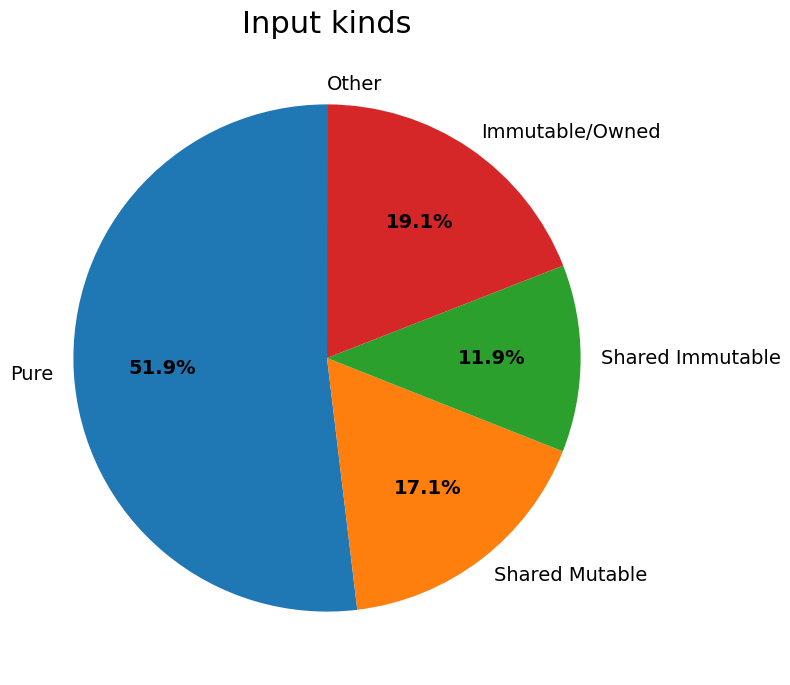

In [44]:
query = """
SELECT
    SUM(t.inputs_pure)             AS pure,
    SUM(t.inputs_shared_mut)       AS shared_mutable,
    SUM(t.inputs_shared_ro)        AS shared_immutable,
    SUM(t.inputs_imm_or_owned)     AS immutable_owned,
    SUM(t.inputs_funds_withdrawal) AS inputs_funds_withdrawal,
    SUM(t.inputs_receiving)        AS inputs_receiving
FROM transactions t
WHERE NOT EXISTS (
    SELECT 1
    FROM object_changes oc
    WHERE oc.transaction_digest = t.transaction_digest
      AND encode(oc.address, 'hex') = ANY(%s)
);
"""

cur.execute(query, (ignored_objects,))

pure, shared_mut, shared_ro, imm_owned, funds_withdrawal, receiving = cur.fetchone()

# =========================
# Prepare pie chart data
# =========================

other = funds_withdrawal + receiving

labels = [
    "Pure",
    "Shared Mutable",
    "Shared Immutable",
    "Immutable/Owned",
    "Other"
]

sizes = [
    pure,
    shared_mut,
    shared_ro,
    imm_owned,
    other
]

# =========================
# Plot
# =========================

# Hide percentage for tiny slices
def autopct_func(pct):
    return f'{pct:.1f}%' if pct >= 1 else ''

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=autopct_func,
    startangle=90,

    labeldistance=1.08,
    pctdistance=0.65,

    textprops={'fontsize': 14}
)

# Make percentages bold
for t in autotexts:
    t.set_weight("bold")
    t.set_fontsize(14)

ax.set_title("Input kinds", fontsize=22)

plt.tight_layout()
plt.show()

In [45]:
query = """SELECT change_type, COUNT(*)
FROM object_changes
GROUP BY change_type
ORDER BY COUNT(*) DESC;"""

cur.execute(query)

count = cur.fetchall()

count

[('mutated', 7100981),
 ('created', 1195748),
 ('deleted', 666710),
 ('unwrapped_then_deleted', 17053),
 ('unwrapped', 546),
 ('wrapped', 399)]

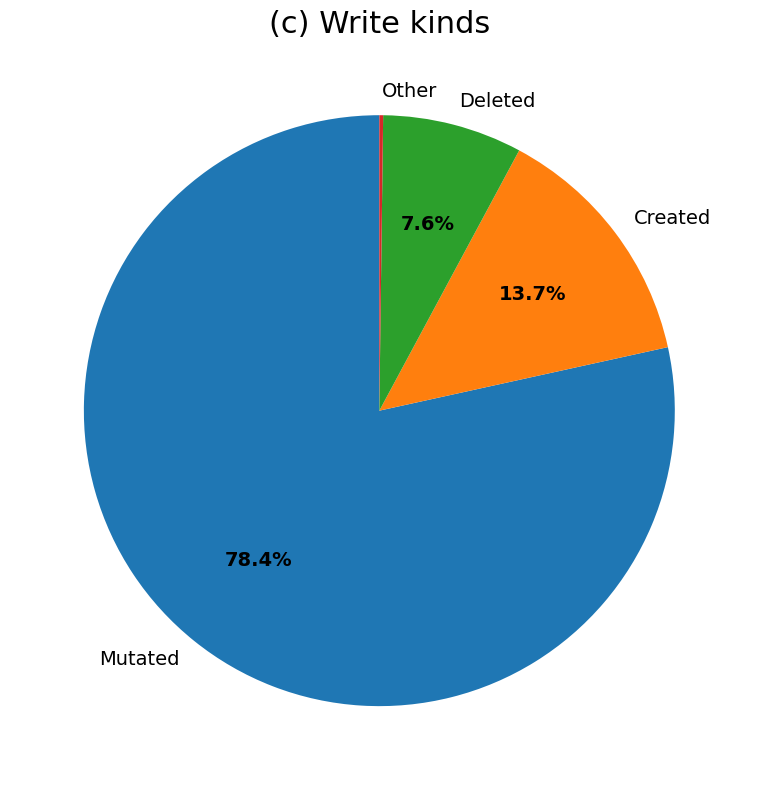

In [46]:
query = """
SELECT
    SUM(CASE WHEN oc.change_type = 'mutated' THEN 1 ELSE 0 END) AS mutated,
    SUM(CASE WHEN oc.change_type = 'created' THEN 1 ELSE 0 END) AS created,
    SUM(CASE WHEN oc.change_type = 'deleted' THEN 1 ELSE 0 END) AS deleted,
    SUM(CASE
            WHEN oc.change_type IN (
                'unwrapped_then_deleted',
                'unwrapped',
                'wrapped'
            )
            THEN 1
            ELSE 0
        END) AS other
FROM object_changes oc
WHERE NOT EXISTS (
    SELECT 1
    FROM object_changes oc2
    WHERE oc2.transaction_digest = oc.transaction_digest
      AND encode(oc2.address, 'hex') = ANY(%s)
);
"""

cur.execute(query, (ignored_objects,))

mutated, created, deleted, other = cur.fetchone()

# =========================
# Prepare data
# =========================

labels = [
    "Mutated",
    "Created",
    "Deleted",
    "Other"
]

sizes = [
    mutated,
    created,
    deleted,
    other
]

# =========================
# Plot pie chart
# =========================

fig, ax = plt.subplots(figsize=(8, 8))

# Custom autopct function
def autopct_func(pct):
    return f'{pct:.1f}%' if pct >= 1 else ''

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=autopct_func,
    startangle=90,

    labeldistance=1.08,
    pctdistance=0.65,

    textprops={'fontsize': 14}
)

# Bold percentages
for t in autotexts:
    t.set_weight("bold")
    t.set_fontsize(14)

ax.set_title("(c) Write kinds", fontsize=22)

plt.tight_layout()
plt.show()

In [47]:
query = """
SELECT
    convert_from(error, 'UTF8') AS error_text,
    COUNT(*) AS count
FROM transactions
WHERE error IS NOT NULL
GROUP BY error_text
ORDER BY count DESC
LIMIT 20;
"""

cur.execute(query)

for row in cur.fetchall():
    print(row)

('Insufficient coin balance for operation.', 10795)
('Move Runtime Abort. Location: caf6ba059d539a97646d47f0b9ddf843e138d215e2a12ca1f4585d386f7aec3a::balance_manager::withdraw_with_proof (function index 20) at offset 55, Abort Code: 3', 5971)
('Certificate is cancelled due to congestion on shared objects: 0xedaa74161d02eed779518c9e11a31f0b29bcc29f5f510d6641ddaf64ec79d858, ', 3059)
('Move Runtime Abort. Location: 0000000000000000000000000000000000000000000000000000000000000002::balance::split (function index 7) at offset 10, Abort Code: 2', 2659)
('Move Runtime Abort. Location: e016516cae4c27eb871870e3b1dd63d45ae180c412677784915b437a7ec930f0::safeV2::deposit (function index 5) at offset 11, Abort Code: 2', 1676)
('Move Runtime Abort. Location: 90290fb6f7accea21c865ccd177fd56b9073e84e86b0751b7a3a53641e02df56::flash_loan::return_flashloan_quote (function index 4) at offset 11, Abort Code: 14680251', 1421)
('Move Runtime Abort. Location: 29b28856344185c97cc72bac90e9601398e8276ee72eba59fc6c

In [49]:
query = """
WITH decoded AS (
    SELECT
        t.transaction_digest,
        convert_from(t.error, 'UTF8') AS error_text
    FROM transactions t
    WHERE t.error IS NOT NULL
)
SELECT
    CASE
        WHEN error_text ILIKE '%%congestion on shared objects%%' THEN 'SharedObjectCongestion'
        WHEN error_text ILIKE '%%abort%%' THEN 'MoveAbort'
        WHEN error_text ILIKE '%%coin balance%%' THEN 'InsufficientCoinBalance'
        WHEN error_text ILIKE '%%insufficient gas%%' THEN 'InsufficientGas'
        ELSE 'Other'
    END AS error_kind,
    COUNT(*) AS count
FROM decoded d
WHERE NOT EXISTS (
    SELECT 1
    FROM object_changes oc
    WHERE oc.transaction_digest = d.transaction_digest
      AND encode(oc.address, 'hex') = ANY(%s)
)
GROUP BY error_kind
ORDER BY count DESC;
"""

cur.execute(query, (ignored_objects,))
rows = cur.fetchall()

labels = [row[0] for row in rows]
sizes = [row[1] for row in rows]

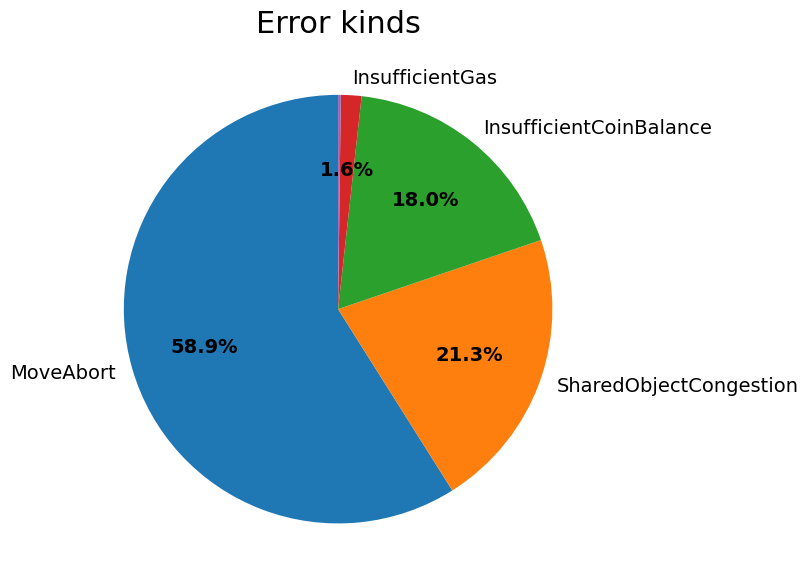

In [50]:
def autopct_func(pct):
    return f'{pct:.1f}%' if pct >= 1 else ''

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=autopct_func,
    startangle=90,
    labeldistance=1.08,
    pctdistance=0.65,
    textprops={'fontsize': 14}
)

# Hide tiny "Other" label
for text, label, size in zip(texts, labels, sizes):
    pct = size / sum(sizes) * 100

    if label == "Other" and pct < 2:
        text.set_visible(False)

# Style percentages
for t in autotexts:
    t.set_weight("bold")
    t.set_fontsize(14)

ax.set_title("Error kinds", fontsize=22)

plt.tight_layout()
plt.show()

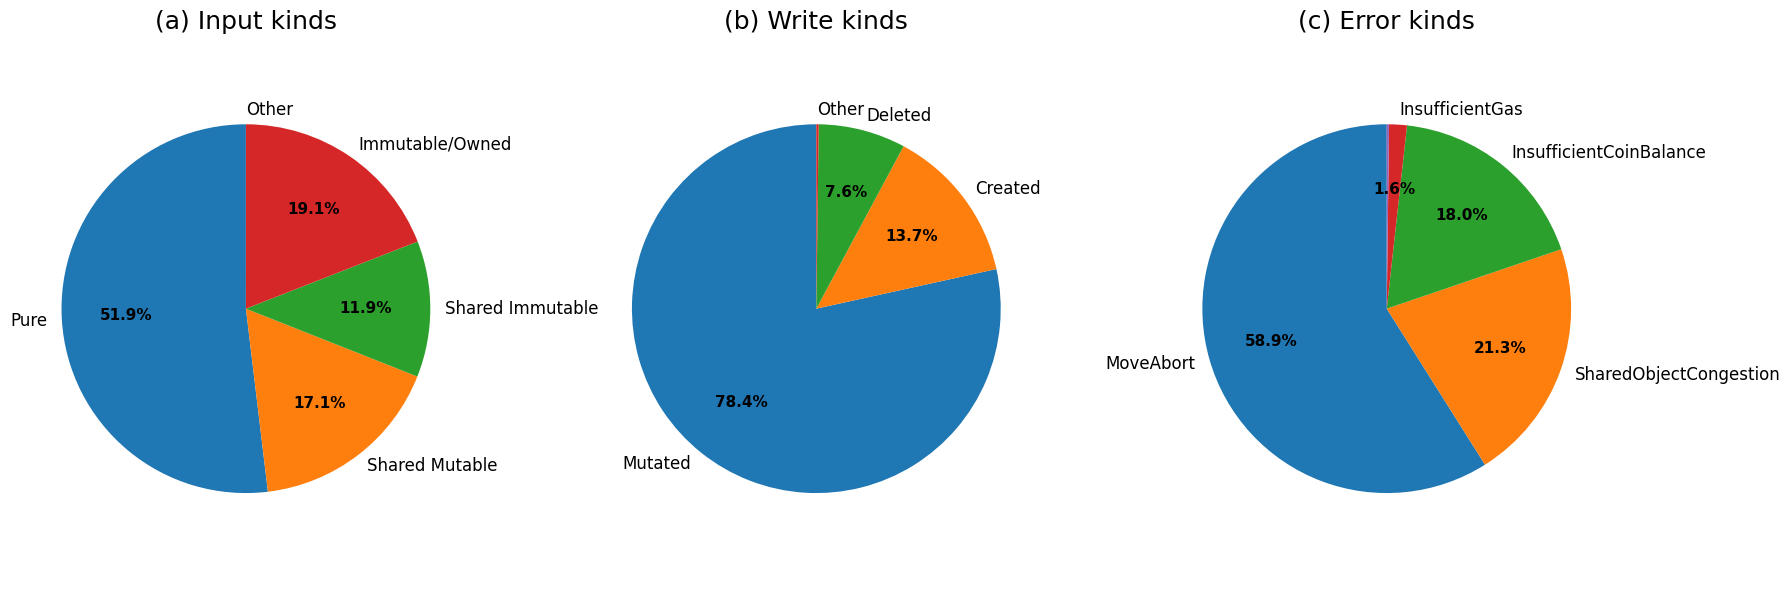

In [51]:
# =========================
# Data for the three pie charts
# =========================

input_labels = [
    "Pure",
    "Shared Mutable",
    "Shared Immutable",
    "Immutable/Owned",
    "Other"
]

input_sizes = [
    pure,
    shared_mut,
    shared_ro,
    imm_owned,
    funds_withdrawal + receiving
]


write_labels = [
    "Mutated",
    "Created",
    "Deleted",
    "Other"
]

write_sizes = [
    mutated,
    created,
    deleted,
    other
]


error_labels = [row[0] for row in rows]
error_sizes = [row[1] for row in rows]


# =========================
# Helper function
# =========================

def plot_pie(ax, sizes, labels, title):
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct=autopct_func,
        startangle=90,
        labeldistance=1.08,
        pctdistance=0.65,
        textprops={"fontsize": 12}
    )

    # Hide tiny "Other" label in error kinds
    for text, label, size in zip(texts, labels, sizes):
        pct = size / sum(sizes) * 100

        if title == "(c) Error kinds":
            if label == "Other" and pct < 2:
                text.set_visible(False)

    for t in autotexts:
        t.set_weight("bold")
        t.set_fontsize(11)

    ax.set_title(title, fontsize=18)
    ax.axis("equal")


# =========================
# Plot all three in one figure
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_pie(
    axes[0],
    input_sizes,
    input_labels,
    "(a) Input kinds"
)

plot_pie(
    axes[1],
    write_sizes,
    write_labels,
    "(b) Write kinds"
)

plot_pie(
    axes[2],
    error_sizes,
    error_labels,
    "(c) Error kinds"
)



plt.tight_layout()
plt.show()